# Predicting Beta Bank Customer Exits

In this project, I develop a machine-learning model to predict whether existing Beta Bank customers will leave the bank soon. 

I use behavior data about past clients and termination of contracts with the bank to train a classification model that will predict which customers are likely to leave.

Using Python, I first import and examine the dataset and prepare the data.

Next, I split the dataset into a training set, a validation set, and a test set. 

Then, I investigate the quality of different models, first ignoring the class imbalance and then employing different strategies to address the class imbalance in the training set. I also tune hyperparameters to identify the best performing mode. Finlly, I check the quality of the model using the test set (setting the F1 threshold at .59) and compare AUC-ROC metric with the F1 score.

## Load and prepare data

First, we load and take a look at the dataset.

In [21]:
# Load pandas
import pandas as pd

# Load data file
churn = pd.read_csv('/datasets/Churn.csv')

# Print the general/summary information about the DataFrame
churn.info()
print()

# Print a sample of the data
print(churn.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    156

Here, we can see that 'Exited' is the target value (categorical, with 1 signifying that the customer left). There are 13 feature columns with data on customer characteristics and behavior (RowNumber, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, and EstimatedSalary). 

A few issues are apparent here. First, the RowNumber, CustomerID, and Surname columns are unnecessary and may even confuse the model. RowNumber and CustomerId values will be unique for each observation, so they're not going to have any predictive value. Surname is also irrelevant, and any overlaps in surnames could introduce noise. It's best to drop these columns from our dataset.

Next, the Tenure column is missing 909 values, or 9% of the data. We'll need to take a look at these to determine how best to handle the missing values before we can train our model. 

Third, we'll need to do some feature scaling since the range of values differs significantly for different features.

Lastly, we have two columns with categorical string data that will need to be converted to numerical values to be able to train our model: Geography and Gender.

We'll start by dropping the three unnecessary columns.

In [22]:
# Drop RowNumber, CustomerId, and Surname columns
churn = churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

Now, let's see if there's any pattern to the missing Tenure values.

In [23]:
# Print a sample of the rows with missing values
print(churn[churn['Tenure'].isna()].head(20))

     CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
30           591     Spain  Female   39     NaN       0.00              3   
48           550   Germany    Male   38     NaN  103391.38              1   
51           585   Germany    Male   36     NaN  146050.97              2   
53           655   Germany    Male   41     NaN  125561.97              1   
60           742   Germany    Male   35     NaN  136857.00              1   
82           543    France  Female   36     NaN       0.00              2   
85           652     Spain  Female   75     NaN       0.00              2   
94           730     Spain    Male   42     NaN       0.00              2   
99           413    France    Male   34     NaN       0.00              2   
111          538   Germany    Male   39     NaN  108055.10              2   
123          684   Germany  Female   48     NaN  126384.42              1   
125          432    France    Male   42     NaN  152603.45              1   

There isn't an obvious pattern to the missing values, they seem to occur across a range of values in the other columns. It could be that the data is missing due to a random system glitch or quality issue, or due to some other reason. Considering the values in the Tenure column refer to "the period of maturation for a customer's fixed deposit (years)" it would make sense for the data to be missing if the customer doesn't have a fixed deposit (e.g., they only have a checking or savings account). However, with only 9% of data missing, it probably makes the most sense to just fill in the missing values with the mean, median, or mode since the amount (less than 10%) won't skew the data too much.

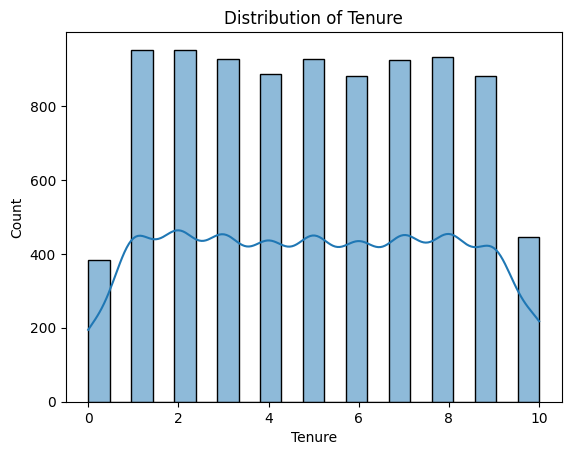

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=churn, x='Tenure', kde=True)
plt.title("Distribution of Tenure")
plt.show()

Based on the existing distribution, median seems best as it will be less affected by the lower frequencies at the low and high ends.

In [25]:
# Fill NaNs in Tenure with the column's median
churn['Tenure'] = churn['Tenure'].fillna(churn['Tenure'].median())

Now we'll encode the two categorical variables using One Hot Encoding (OHE). This should give us decent enough results even though it's not optimal for tree models.

In [26]:
# Perform OHE on categorical columns and drop the first category to avoid dummy trap
churn_ohe = pd.get_dummies(churn, drop_first=True)
print(churn_ohe.head())

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42     2.0       0.00              1          1   
1          608   41     1.0   83807.86              1          0   
2          502   42     8.0  159660.80              3          1   
3          699   39     1.0       0.00              2          0   
4          850   43     2.0  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1                  0   
1               1        112542.58       0                  0   
2               0        113931.57       1                  0   
3               0         93826.63       0                  0   
4               1         79084.10       0                  0   

   Geography_Spain  Gender_Male  
0                0            0  
1                1            0  
2                0            0  
3                0            0  
4                1            

We'll scale our features after splitting our dataset. Before we split, we'll take a look at the balance of classes. 

0    0.7963
1    0.2037
Name: Exited, dtype: float64


<AxesSubplot:>

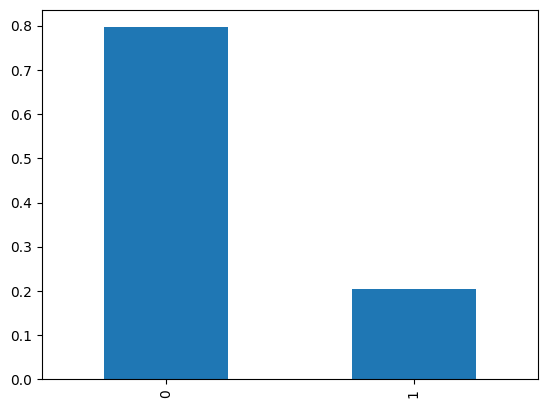

In [27]:
# Count values in target column
class_frequency = churn['Exited'].value_counts(normalize=True) 
print(class_frequency)
# Visualize balance of classes
class_frequency.plot(kind='bar')

We have a strong class imbalance. We'll use the stratify parameter when splitting our dataset so each subset keeps the same balance.

In [28]:
# Import splitting function
from sklearn.model_selection import train_test_split

# Separate features and target
target = churn_ohe['Exited']
features = churn_ohe.drop('Exited', axis=1)

# First split: training set (60%) and temp (40%)
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=12345, stratify=target
)

# Second split: split temp into validation set (20%) and test set (20%)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=12345, stratify=target_temp
)

# Print the size of the tables stored in the six variables
print(features_train.shape)
print(target_train.shape)
print(features_valid.shape)
print(target_valid.shape)
print(features_test.shape)
print(target_test.shape)

(6000, 11)
(6000,)
(2000, 11)
(2000,)
(2000, 11)
(2000,)


Now we'll scale our features.

In [29]:
# Import data standardizing class
from sklearn.preprocessing import StandardScaler

# Define list of numeric features
numeric = ['CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'EstimatedSalary']

# Create instance of class and tune it on training data
scaler = StandardScaler()
scaler.fit(features_train[numeric])

# Silence SettingWithCopy Warning
pd.options.mode.chained_assignment = None

# Transform training, validation, and test sets
features_train[numeric] = scaler.transform(features_train[numeric])
features_valid[numeric] = scaler.transform(features_valid[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])

print(features_train.head())


      CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
2837    -1.040434  0.953312  0.360600  0.774657      -0.914708          0   
9925     0.454006 -0.095244 -0.002786  1.910540      -0.914708          1   
8746     0.103585 -0.476537  1.087371  0.481608       0.820981          0   
660     -0.184996  0.190726 -0.002786  0.088439      -0.914708          1   
3610    -0.720933  1.620574 -1.456328  0.879129      -0.914708          1   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
2837               1        -0.119110                  1                0   
9925               1        -0.258658                  0                0   
8746               1         1.422836                  0                0   
660                1        -1.160427                  1                0   
3610               0         0.113236                  0                0   

      Gender_Male  
2837            0  
9925            0  
8746          

Now we can begin training our model.

## Train model (without balancing classes)

In this step, we'll train three models (Decision Tree, Random Forest, and Logistic Regression) without taking into account the class imbalance. We'll check the F1 score of these models using the validation set.

We'll start with training a decision tree model.

In [30]:
# Import DecisionTreeClassifier and F1_score from sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Train model
model = DecisionTreeClassifier(random_state=12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

# Calculate F1 score
f1 = f1_score(target_valid, predicted_valid) 
print(f1)

0.5035971223021583


This is falling a bit short of our .59 threshold. Let's see if a Random Forest model does any better.

In [31]:
# Import RandomForestClassifier from sklearn
from sklearn.ensemble import RandomForestClassifier

# Train model
model = RandomForestClassifier(random_state=12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

# Calculate F1 score
f1 = f1_score(target_valid, predicted_valid) 
print(f1)

0.6126656848306332


Random Forest looks like it was quite a bit better! Let's see how a Logistic Regression model performs.

In [32]:
# Import LogisticRegression from sklearn
from sklearn.linear_model import LogisticRegression

# Train model
model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

# Calculate F1 score
f1 = f1_score(target_valid, predicted_valid) 
print(f1)

0.3076923076923077


Logistic Regression performs the worst out of the three.

Let's see if we can further improve these models by taking into account the imbalance of classes.

## Improve Quality of the model

In this step, we'll try some techniques for fixing our class imbalance to improve our F1 score including class weight adjustment, upsampling, downsampling, and threshold adjustment.

We'll start with class weight adjustment.

In [33]:
# Train Decision Tree model
model = DecisionTreeClassifier(random_state=12345, class_weight='balanced')
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

# Calculate F1 score
f1 = f1_score(target_valid, predicted_valid) 
print('Decision Tree F1:', f1)

# Train Random Forest model
model = RandomForestClassifier(random_state=12345, class_weight='balanced')
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

# Calculate F1 score
f1 = f1_score(target_valid, predicted_valid) 
print('Random Forest F1:',f1)

# Train Logistic Regression model
model = LogisticRegression(random_state=12345, solver='liblinear', class_weight='balanced')
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

# Calculate F1 score
f1 = f1_score(target_valid, predicted_valid) 
print('Logistic Regression F1:',f1)

Decision Tree F1: 0.5152625152625153
Random Forest F1: 0.5783866057838661
Logistic Regression F1: 0.5289982425307558


This seemed to help our Logistic Regression model, but it didn't help our Decision Tree much and actually made the Random Forest perform a bit worse. This indicates that for the Random Forest model, predicting more exits is causing precision to fall more than it's causing recall to rise.

Next, we'll try upsampling and downsampling. We'll define functions to split the training sample into negative and positive observations, duplicate positive / negative class observations, and shuffle the rows.

In [34]:
# Import shuffle 
from sklearn.utils import shuffle

# Define upsampling function
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]
    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    # add shuffle
    features_upsampled, target_upsampled = shuffle(features_upsampled, target_upsampled,  random_state=12345)
    return features_upsampled, target_upsampled

# Run upsampling function, duplicating positive observations 4 times to match the negative observations
features_upsampled, target_upsampled = upsample(
    features_train, target_train, 4
)

# Train models with new upsampled data
model = DecisionTreeClassifier(random_state=12345)
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
print('Decision Tree F1:', f1_score(target_valid, predicted_valid))

model = RandomForestClassifier(random_state=12345)
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
print('Random Forest F1:', f1_score(target_valid, predicted_valid))

model = LogisticRegression(solver='liblinear', random_state=12345)
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
print('Logistic Regression F1:', f1_score(target_valid, predicted_valid))

Decision Tree F1: 0.5251533742331288
Random Forest F1: 0.6358839050131926
Logistic Regression F1: 0.5246753246753246


Upsampling improves all three models, with the upsampled Random Forest model now peforming the best on the F1 metric. We'll see if downsampling has similar results.

In [35]:
# Define downsampling function
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]
    features_downsampled = pd.concat([features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones]) 
    target_downsampled = pd.concat([target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones]) 
    # add shuffle
    features_downsampled, target_downsampled = shuffle(features_downsampled, target_downsampled, random_state=12345)
    return features_downsampled, target_downsampled

# Run downsampling function, sampling 1/4 of the negative observations to match the positive observations
features_downsampled, target_downsampled = downsample(
    features_train, target_train, 0.25
)

# Train models with new downsampled data
model = DecisionTreeClassifier(random_state=12345)
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
print('Decision Tree F1:', f1_score(target_valid, predicted_valid))

model = RandomForestClassifier(random_state=12345)
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
print('Random Forest F1:', f1_score(target_valid, predicted_valid))

model = LogisticRegression(solver='liblinear', random_state=12345)
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
print('Logistic Regression F1:', f1_score(target_valid, predicted_valid))

Decision Tree F1: 0.49161073825503354
Random Forest F1: 0.5984848484848485
Logistic Regression F1: 0.5275862068965517


Downsampling looks it it improves the Logistic Regression model but causes the Decision Tree and Random Forest models to perform slightly worse.

So far, the Random Forest model trained on upsampled data seems to be performing best. Let's see if tuning hyperparameters for this model can produce even better results.

In [ ]:
# import GridSearchCV
from sklearn.model_selection import GridSearchCV


# Define the parameter grid
param_grid = {
    'n_estimators': range(1, 50),       
    'max_depth': range(1,11)   
}

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=12345), param_grid=param_grid, cv=5, scoring='f1')

# Fit the model on upsampled data
grid_search.fit(features_upsampled, target_upsampled)

# Get the best parameters and estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("F1 of the best random forest model on the training set:", grid_search.best_score_)

# Evaluate best model on the validation set
predicted_valid = best_model.predict(features_valid)
f1 = f1_score(target_valid, predicted_valid)
print("F1 score of the best random forest model on the validation set:", f1)


This method identifies the best model with max_depth 10 and n_estimators 43. While the F1 score is higher on the training set, indicating some overfitting, the F1 score for the validation set has still improved a bit.

Now, we'll do some threshold tuning.

In [ ]:
# Import NumPy
import numpy as np

# Define class probabilities
probabilities_valid = best_model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]

# Go through threshold values from 0 to 0.5 in increments of .02 and find F1 score for each value
for threshold in np.arange(0, 1.0, 0.02):
    predicted_valid = probabilities_one_valid > threshold  
    f1 = f1_score(target_valid, predicted_valid)
    
    print('Threshold = {:.2f} | F1 = {:.3f}'.format(threshold, f1))



The default threshold of .5 gives us the highest F1 score, so we'll stick with that.

## Final testing

In this step, we'll check the F1 score of our best model on the test set. Additionally, we'll measure the AUC-ROC metric and compare it with the F1 score.

First, we'll combine the validation set back into the training set and train our best model on this larger set.

In [ ]:
# Run upsampling function on validation set
features_val_upsampled, target_val_upsampled = upsample(
    features_valid, target_valid, 4
)

# Combine validation set back into training set
features_final_train = pd.concat([features_upsampled, features_val_upsampled], ignore_index=True)
target_final_train = pd.concat([target_upsampled, target_val_upsampled], ignore_index=True)

# Train on training set
best_model.fit(features_final_train, target_final_train)


Now we'll check the F1 score on the test set.

In [ ]:
# Calculate F1 for test set
test_predictions = best_model.predict(features_test)
test_f1 = f1_score(target_test, test_predictions)
# Print results
print('F1 score on test set:', test_f1)

This slightly exceeds our F1 requirement of .59. We'll also measure the AUC-ROC metric.

In [ ]:
# Import roc_auc_score, roc_curve, and pyplot
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
probabilities_one_test = best_model.predict_proba(features_test)[:, 1]

# Compute AUC-ROC
roc_auc = roc_auc_score(target_test, probabilities_one_test)
print(f"AUC-ROC: {roc_auc:.4f}")


# Plot ROC curve
fpr, tpr, thresholds = roc_curve(target_test, probabilities_one_test)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

The AUC-ROC score of .85 tells us that our best model is doing well with ranking classes. The chart also shows that the model is performing better than the baseline random model. However, the lower F1 score tells us that the model still has some misclassifications. This makes sense considering the F1 score is more sensitive to class imbalance. While we did address the class imbalance with upsampling, this isn't a perfect substitute for actually having more data on customers who exited.

## Conclusion

In this project, I developed a machine learning model to predict customer churn at Beta Bank. After preparing the dataset and addressing issues like missing values, irrelevant features, and class imbalance, I trained multiple classification models to evaluate their performance. Among Decision Tree, Logistic Regression, and Random Forest, the Random Forest model consistently outperformed the others on F1 score.

To address the significant class imbalance, I experimented with class weighting, upsampling, and downsampling. Upsampling yielded the best results, especially when combined with hyperparameter tuning. The final model — a Random Forest classifier with tuned max_depth and n_estimators — was trained on an expanded training set and evaluated on a held-out test set.

The model achieved an F1 score of 0.60 and an AUC-ROC score of 0.85 on the test set. The high AUC-ROC indicates that the model is strong at ranking which customers are likely to exit, while the moderate F1 score reflects the challenge of accurately classifying rare exit cases. This suggests that while our model can prioritize high-risk customers for targeted intervention, further improvements could be made by gathering more exit data or engineering additional behavioral features.